In [21]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Q4 — Llama-3 Zero-shot and Few-shot Classification on 20 Newsgroups

**HSLU NALAPRO project — Question 4.** _Author: Dan Waititu (`danwwaititu@gmail.com`)._

## Research question

> _"Using Llama-3 run zero-shot and few-shot learning experiments. Evaluate and discuss the results."_ — `project_description/NALAPRO Project.pdf`, §2 Question 4.

Whereas Q2 (BERT fine-tune) and Q3 (MLM-then-fine-tune) update model weights with task supervision, this notebook freezes Llama-3 entirely and asks the model to classify each post by following an instruction prompt. The only training-set information the model gets is whatever appears in the prompt itself: in the **zero-shot** condition that is just the list of 20 newsgroup names; in the **few-shot** conditions we add 1 or 3 example documents per class so the model can pattern-match.

## Self-contained

This notebook does **not** import from the `nlp_project` package — every helper it needs is defined inline below (sections 3 and 4). That means it runs unchanged on Google Colab without cloning the repo, and on a local NVIDIA 3060 laptop with just the runtime dependencies installed. The trade-off is some duplication versus the rest of the project; for Q4 we judged portability more important than DRY.

## Conditions tested in this notebook

| Run name | k (demos / class) | Total demos in prompt | W&B run |
|---|---:|---:|---|
| Zero-shot | 0 | 0 | `q4-zero-shot` |
| Few-shot (1/class) | 1 | 20 | `q4-few-shot-1pc` |
| Few-shot (3/class) | 3 | 60 | `q4-few-shot-3pc` |

All three are evaluated on the **same stratified 200-document test subsample** (10 per class, seed 42) so the comparison isolates the effect of in-context examples.

## Model and hardware

- **Model**: `meta-llama/Llama-3.2-3B-Instruct`. The smallest Llama-3 family member with a chat template; fits in ≈ 2 GB of VRAM under 4-bit nf4 quantization, so the notebook runs comfortably on a 6 GB NVIDIA 3060 laptop or a Colab free T4.
- **Quantization**: 4-bit nf4 with bf16 compute (via `bitsandbytes`). Same on both hosts so the numbers are comparable between runs.
- **Decoding**: greedy (`do_sample=False`), `max_new_tokens=15` — labels are short; greedy means identical inputs always give identical outputs.

## Deliverables produced by this notebook

- `models/q4_results/q4_zero_shot.json`, `q4_few_shot_1pc.json`, `q4_few_shot_3pc.json` — per-run metrics (accuracy, macro-F1, per-class F1, confusion matrix, invalid-rate).
- `figures/q4_confusion_{zero,1pc,3pc}.png` — confusion matrices per condition.
- `figures/q4_comparison_bars.png` — accuracy + macro-F1 across the three Llama runs.
- `figures/q4_vs_q2b_bars.png` — Llama runs vs the Q2b supervised baseline (if `models/q2_results/q2b_baseline.json` is present locally).

## W&B runs

Project `hslu-nalapro`, group `q4`, three runs (one per condition). Paste the URLs below once executed:

- <https://wandb.ai/danwwaititu-hochschule-luzern/hslu-nalapro?nw=nwuserdanwwaititu> _(group `q4`)_

## AI tool disclosure

Per spec §7, this notebook (cells + markdown) was co-authored with **Claude Code** (Anthropic, model `claude-opus-4-7`). The choice of model size, quantization scheme, subsample size, few-shot strategy, label-parsing heuristic, and the discussion section below reflect the author's judgement. The numerical results are reproduced from single local executions; seed is `SEED = 42` throughout.

## 1. Environment setup — local vs Google Colab

This notebook runs unchanged on two hosts:

1. **Local NVIDIA 3060 laptop** — Python 3.10+, `pip install transformers accelerate bitsandbytes wandb scikit-learn seaborn pandas tqdm matplotlib numpy torch`. (The HSLU repo also has a `uv` setup — `uv sync --extra llm` installs the same set — but you don't need any project file to run this notebook.)
2. **Google Colab (free GPU)** — open the notebook, run the cell below; it installs the runtime deps and prompts for Hugging Face + Weights & Biases logins.

**No repo clone, no `pip install -e .`.** Every helper this notebook uses is defined inline in sections 3 and 4. The cell below detects the environment, installs deps if needed, and prints a device summary so you know GPU acceleration is actually active.

In [1]:
# --- detect environment ---------------------------------------------------
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f'IN_COLAB = {IN_COLAB}')

if IN_COLAB:
    # On Colab we install runtime deps + interactively log in to HF (gated model) and W&B.
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', '-q', 'install',
        'transformers>=4.45', 'accelerate>=0.34', 'bitsandbytes>=0.43',
        'wandb', 'scikit-learn', 'seaborn', 'pandas', 'tqdm'])
    from huggingface_hub import notebook_login as hf_login
    hf_login()
    import wandb
    wandb.login()

# --- device sanity check (both hosts) -------------------------------------
import torch
if torch.cuda.is_available():
    print(f'CUDA OK — device 0 = {torch.cuda.get_device_name(0)}')
    free, total = torch.cuda.mem_get_info()
    print(f'free / total VRAM = {free / 1e9:.2f} / {total / 1e9:.2f} GB')
else:
    print('WARNING: no CUDA detected. The notebook will fall back to bf16/fp32 on CPU/MPS,')
    print('which is far too slow for the 200-doc test subsample — use a GPU host.')


IN_COLAB = True


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: danwwaititu (danwwaititu-hochschule-luzern) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


CUDA OK — device 0 = NVIDIA L4
free / total VRAM = 23.46 / 23.66 GB


## 2. Imports, seed, output directories

Standard scientific stack plus `transformers`, `wandb`, and `sklearn`. We define `SEED` and `set_seed` inline (instead of importing from the project package) so the notebook is self-contained.

**Why seed everything:** greedy decoding doesn't strictly need a seed, but stratified subsampling and demo selection do — different seeds would change which 200 test docs and which demos the model sees, and therefore the headline numbers. We use `SEED = 42` throughout, matching Q1–Q3.

In [2]:
import json
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import wandb
from sklearn.model_selection import train_test_split

SEED = 42

def set_seed(seed: int = SEED) -> None:
    """Seed Python, NumPy, env-hash, and PyTorch (CPU + CUDA) from one constant."""
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

DEVICE = (
    'cuda' if torch.cuda.is_available()
    else 'mps' if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available()
    else 'cpu'
)
print(f'device = {DEVICE}; seed = {SEED}')

# Outputs land relative to the notebook's working directory. On Colab that's /content;
# locally it depends on where Jupyter was launched. Both paths are created if missing.
RESULTS_DIR = Path('models/q4_results'); RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = Path('figures'); FIG_DIR.mkdir(parents=True, exist_ok=True)
# Optional comparison-vs-Q2b: only used if the file already exists locally (it won't on Colab).
Q2_BASELINE = Path('models/q2_results/q2b_baseline.json')
print('results ->', RESULTS_DIR.resolve())
print('figures ->', FIG_DIR.resolve())


device = cuda; seed = 42
results -> /content/models/q4_results
figures -> /content/figures


## 3. Inline helpers — data, metrics, plotting

Three small utilities, defined here so the notebook does not depend on the `nlp_project` package:

- **`load_20ng(remove=True)`** — fetch the 20 Newsgroups train/test splits from sklearn.   `remove=True` strips headers/footers/quoted text (those leak the label; spec §3).
- **`metrics_from_predictions(y_true, y_pred, label_names)`** — accuracy, macro-F1,   per-class F1, and confusion matrix in one shot. Uses the full label range so classes   that the model never predicts still occupy a slot.
- **`plot_confusion(cm, label_names, save_path, title)`** — seaborn heatmap with class   names on both axes, saved as PNG.

These are byte-for-byte equivalent to the implementations in `src/nlp_project/{data,eval}.py` — copied inline only to make this notebook portable.

In [3]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.metrics import accuracy_score, confusion_matrix as _cm, f1_score

def load_20ng(remove: bool = True):
    """Fetch 20 Newsgroups. Returns (train_docs, train_labels, test_docs, test_labels, label_names).

    When `remove=True` (default), strips headers, footers, and quoted text — those
    contain the newsgroup name and similar tells that trivialise the task.
    """
    remove_tuple = ('headers', 'footers', 'quotes') if remove else ()
    tr = fetch_20newsgroups(subset='train', remove=remove_tuple)
    te = fetch_20newsgroups(subset='test',  remove=remove_tuple)
    return list(tr.data), np.asarray(tr.target), list(te.data), np.asarray(te.target), list(tr.target_names)

def metrics_from_predictions(y_true, y_pred, label_names):
    """Standard classification metrics from already-computed predictions.

    Returns dict with `accuracy`, `macro_f1`, `per_class_f1` (length n_classes),
    and `confusion_matrix` (n_classes x n_classes).
    """
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    labels = list(range(len(label_names)))
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'per_class_f1': f1_score(y_true, y_pred, average=None, labels=labels, zero_division=0),
        'confusion_matrix': _cm(y_true, y_pred, labels=labels),
    }

def plot_confusion(cm, label_names, save_path, title='Confusion matrix'):
    """Seaborn heatmap of a confusion matrix, saved as PNG."""
    fig, ax = plt.subplots(figsize=(0.5 * len(label_names) + 2, 0.5 * len(label_names) + 2))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names, cbar=False, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    fig.tight_layout(); fig.savefig(save_path, dpi=150); plt.close(fig)
    print('Saved figure ->', save_path)


## 4. Inline helpers — Llama classification

Five small functions, defined inline so this notebook is self-contained:

- **`SYSTEM_PROMPT`** — the system message template listing the 20 allowed labels.
- **`build_prompt(doc, label_names, demos=None, truncate_chars=1500)`** — assembles the   chat-template messages list (system + optional alternating user/assistant demo turns +   final user query). Documents are truncated to keep the prompt short.
- **`select_demos(train_docs, train_labels, label_names, k_per_class, seed=42)`** —   stratified per-class demo selection from the training set, deterministic given `seed`.   Uses a local RNG (`np.random.default_rng(seed)`) so callers can vary the seed without   disturbing global NumPy state.
- **`parse_label(raw_output, label_names)`** — maps the model's generated text to a label   index. Strategy: lowercase normalize → exact match → substring match (longest wins) →   `difflib.get_close_matches(cutoff=0.6)` fuzzy fallback. Returns `(idx, invalid_flag)`;   unmatched outputs return `(0, True)` so the metrics functions still get a valid index.
- **`load_llama(model_name, quantize_4bit=True, device='auto')`** — loads   `AutoModelForCausalLM` + tokenizer. On CUDA with `bitsandbytes`, uses 4-bit nf4 with   bf16 compute (~ 2 GB for the 3B model). Anywhere else, falls back to bf16/fp32 — this   keeps the notebook importable on a CPU/MPS box for code inspection.
- **`classify_one`** / **`classify_batch`** — single-doc greedy generation + the loop. We   iterate one document at a time because batched chat-template inputs require left-padding   + per-row attention masks; the bookkeeping is fiddly and the speedup is modest on a   single 6 GB GPU.

**Why generative + fuzzy parse rather than logit scoring?** Logit scoring (compute `log P(label | prompt)` for each of 20 labels and argmax) is always valid but slow (one forward pass per label per document) and does not test the model's instruction-following — which is the actual capability under evaluation. We go generative and track an `invalid_rate` diagnostic for outputs the parser cannot map to any label.

In [4]:
import difflib
from collections.abc import Sequence
from typing import Any

SYSTEM_PROMPT = (
    'You are a text classifier for the 20 Newsgroups dataset. Given a Usenet '
    'post, respond with exactly one label from the following list and nothing '
    'else \u2014 no explanation, no punctuation around the label.\n\n'
    'Allowed labels: {labels}'
)

def build_prompt(doc, label_names, demos=None, truncate_chars=1500):
    """Chat-template messages list for one document. `demos` is a list of
    `(doc, label_index)` tuples that become user/assistant turn pairs.
    """
    messages = [{'role': 'system', 'content': SYSTEM_PROMPT.format(labels=', '.join(label_names))}]
    for demo_doc, demo_label in (demos or []):
        messages.append({'role': 'user', 'content': demo_doc[:truncate_chars] + '\n\nLabel:'})
        messages.append({'role': 'assistant', 'content': label_names[demo_label]})
    messages.append({'role': 'user', 'content': doc[:truncate_chars] + '\n\nLabel:'})
    return messages

def select_demos(train_docs, train_labels, label_names, k_per_class, seed=SEED):
    """Stratified demo selection — `k_per_class` docs per newsgroup. Deterministic given `seed`."""
    rng = np.random.default_rng(seed)
    train_labels = np.asarray(train_labels)
    out = []
    for class_idx in range(len(label_names)):
        candidates = np.flatnonzero(train_labels == class_idx)
        if len(candidates) == 0:
            continue
        take = min(k_per_class, len(candidates))
        chosen = rng.choice(candidates, size=take, replace=False)
        for idx in chosen:
            out.append((train_docs[int(idx)], int(class_idx)))
    return out

def _normalize(text: str) -> str:
    """Lowercase, strip, replace dots/underscores with spaces for fuzzy matching."""
    return text.strip().lower().replace('.', ' ').replace('_', ' ')

def parse_label(raw_output, label_names):
    """Map generated text -> (label_index, invalid_flag).

    Strategy: exact normalized match -> substring (longest wins) -> difflib fuzzy.
    Unmatched outputs return (0, True); the bool flag drives the `invalid_rate` diagnostic.
    """
    norm_out = _normalize(raw_output)
    norm_labels = [_normalize(l) for l in label_names]
    for i, nl in enumerate(norm_labels):
        if norm_out == nl:
            return i, False
    matches = []
    for i, nl in enumerate(norm_labels):
        if nl in norm_out or (norm_out and norm_out in nl):
            matches.append((i, len(nl)))
    if matches:
        matches.sort(key=lambda x: -x[1])
        return matches[0][0], False
    close = difflib.get_close_matches(norm_out, norm_labels, n=1, cutoff=0.6)
    if close:
        return norm_labels.index(close[0]), False
    return 0, True


In [5]:
from transformers import AutoModelForCausalLM, AutoTokenizer

def load_llama(model_name='meta-llama/Llama-3.2-3B-Instruct',
               quantize_4bit=True, device='auto', dtype=None):
    """Load an instruct Llama-3 + tokenizer.

    On CUDA with `bitsandbytes`, uses 4-bit nf4 + bf16 compute (~ 2 GB for the 3B model).
    Anywhere else, falls back to bf16/fp32 so the notebook stays importable on dev boxes.
    """
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    if tokenizer.pad_token_id is None:
        # Llama-3 instruct tokenizers ship without a pad token; reuse EOS.
        tokenizer.pad_token = tokenizer.eos_token

    use_4bit = bool(quantize_4bit and torch.cuda.is_available())
    if use_4bit:
        try:
            import bitsandbytes  # noqa: F401
            from transformers import BitsAndBytesConfig
            bnb = BitsAndBytesConfig(
                load_in_4bit=True, bnb_4bit_quant_type='nf4',
                bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True,
            )
            model = AutoModelForCausalLM.from_pretrained(
                model_name, quantization_config=bnb, device_map=device,
            )
        except ImportError:
            use_4bit = False

    if not use_4bit:
        if dtype is None:
            if torch.cuda.is_available() or (hasattr(torch.backends, 'mps') and torch.backends.mps.is_available()):
                dtype = torch.bfloat16
            else:
                dtype = torch.float32
        model = AutoModelForCausalLM.from_pretrained(
            model_name, torch_dtype=dtype,
            device_map=device if device != 'auto' else None,
        )
        if device == 'auto':
            if torch.cuda.is_available():
                model = model.to('cuda')
            elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
                model = model.to('mps')
    model.eval()
    return model, tokenizer

def classify_one(model, tokenizer, doc, label_names, demos=None,
                 max_new_tokens=15, truncate_chars=1500):
    """Greedy classification of one document. Returns (pred_idx, raw_output, invalid_flag)."""
    messages = build_prompt(doc, label_names, demos=demos, truncate_chars=truncate_chars)
    prompt_text = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, tokenize=False,
    )
    inputs = tokenizer(prompt_text, return_tensors='pt').to(model.device)
    with torch.no_grad():
        out = model.generate(
            **inputs, max_new_tokens=max_new_tokens,
            do_sample=False, num_beams=1, pad_token_id=tokenizer.eos_token_id,
        )
    new_tokens = out[0, inputs['input_ids'].shape[1]:]
    raw = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
    pred_idx, invalid = parse_label(raw, label_names)
    return pred_idx, raw, invalid

def classify_batch(model, tokenizer, docs, label_names, demos=None,
                   max_new_tokens=15, truncate_chars=1500, progress=True):
    """Loop classify_one over `docs`. Returns dict with y_pred, raw_outputs, invalid_mask."""
    y_pred = np.zeros(len(docs), dtype=np.int64)
    invalid_mask = np.zeros(len(docs), dtype=bool)
    raw_outputs = []
    iterator = enumerate(docs)
    if progress:
        try:
            from tqdm.auto import tqdm
            iterator = enumerate(tqdm(docs, desc='classifying'))
        except ImportError:
            pass
    for i, doc in iterator:
        pred_idx, raw, invalid = classify_one(
            model, tokenizer, doc, label_names,
            demos=demos, max_new_tokens=max_new_tokens, truncate_chars=truncate_chars,
        )
        y_pred[i] = pred_idx
        raw_outputs.append(raw)
        invalid_mask[i] = invalid
    return {'y_pred': y_pred, 'raw_outputs': raw_outputs, 'invalid_mask': invalid_mask}


## 5. Data — 20 Newsgroups + stratified test subsample

**Load.** Same call as Q1–Q3: `load_20ng(remove=True)`. Headers/footers/quoted text are stripped because they leak the label (spec §3, *label leakage*). Keeping this consistent across all four questions is what makes the cross-experiment comparison meaningful.

**Why subsample.** The 20NG test set has 7 532 documents. At ~2–3 s per document with Llama-3.2-3B in 4-bit on a 3060, a single condition would take ~5–6 hours; three conditions would be a full day. We take a **stratified subsample of 200 documents (10 per class)** — fast enough to run all three conditions in roughly an hour, while still giving us 10 samples per class to estimate per-class F1.

**Statistical limitation.** A 200-doc subsample has a binomial 95% CI of ±1.96 · √(p·(1-p)/200) ≈ ±6 percentage points around accuracy = 0.5. So small between-condition deltas should be read with caution; we flag this in the discussion.

In [6]:
train_docs, train_labels, test_docs, test_labels, label_names = load_20ng(remove=True)
print(f'train docs: {len(train_docs):>6d}')
print(f'test docs : {len(test_docs):>6d}')
print(f'classes   : {len(label_names):>6d}')

# Stratified 200-doc subsample (10 / class). test_size=200 + stratify=labels
# guarantees 10 docs per class because 200 / 20 == 10.
_, eval_docs, _, eval_labels = train_test_split(
    test_docs, test_labels,
    train_size=len(test_docs) - 200,
    test_size=200,
    stratify=test_labels,
    random_state=SEED,
)
eval_docs = list(eval_docs)
eval_labels = np.asarray(eval_labels)
print(f'eval subset: {len(eval_docs)} docs')
print('per-class counts in eval subset:')
pd.Series(eval_labels).value_counts().sort_index().rename(
    index={i: n for i, n in enumerate(label_names)}
)


train docs:  11314
test docs :   7532
classes   :     20
eval subset: 200 docs
per-class counts in eval subset:


,count
alt.atheism,8
comp.graphics,10
comp.os.ms-windows.misc,10
comp.sys.ibm.pc.hardware,10
comp.sys.mac.hardware,10
comp.windows.x,10
misc.forsale,10
rec.autos,11
rec.motorcycles,11
rec.sport.baseball,11


## 6. Load Llama-3.2-3B-Instruct in 4-bit

**Why 4-bit nf4.** Full-precision Llama-3.2-3B is ≈ 6 GB; in bf16 ≈ 6 GB; in 4-bit nf4 with double quantization it is ≈ 2 GB of weights plus activation memory. That fits comfortably on a 6 GB 3060 even at our k=3/class context length.

**Why this matters for fairness.** Quantization changes the numerical behaviour of the model slightly versus the bf16 reference. We run *all three conditions* with the same 4-bit configuration so the comparison between zero/few-shot is internally consistent.

**Gated model.** Llama-3.2-3B-Instruct is gated on Hugging Face; the first run will fail if you haven't requested access on the model page and logged in. The Colab setup cell above (`hf_login`) handles this interactively.

In [7]:
MODEL_NAME = 'meta-llama/Llama-3.2-3B-Instruct'
# MODEL_NAME = 'unsloth/Llama-3.2-3B-Instruct'


model, tokenizer = load_llama(MODEL_NAME, quantize_4bit=True, device='auto')
n_params = sum(p.numel() for p in model.parameters()) / 1e9
print(f'loaded {MODEL_NAME}: {n_params:.2f} B parameters')
if torch.cuda.is_available():
    print(f'VRAM allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB')
    print(f'VRAM reserved : {torch.cuda.memory_reserved() / 1e9:.2f} GB')


config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

loaded meta-llama/Llama-3.2-3B-Instruct: 1.80 B parameters
VRAM allocated: 2.25 GB
VRAM reserved : 6.38 GB


## 7. Prompt walkthrough — what does the model actually see?

It is easy to get prompting wrong silently, so we render one full chat-template prompt for the first eval document and print it. This is the literal string fed to the model (after BPE tokenization).

**Structure for zero-shot:**
1. A *system* message listing the 20 allowed labels and instructing the model to reply with exactly one of them.
2. A *user* message containing the (truncated to 1500 chars) document and a trailing `Label:` cue.

**For few-shot,** demonstration documents are inserted as alternating user / assistant turns before the final user query — the standard chat-template way to do in-context learning with an instruction-tuned model.

In [8]:
# Render the zero-shot prompt for the first eval doc.
msgs_zero = build_prompt(eval_docs[0], label_names, demos=None, truncate_chars=1500)
prompt_zero = tokenizer.apply_chat_template(msgs_zero, add_generation_prompt=True, tokenize=False)
print('=' * 72)
print('ZERO-SHOT PROMPT (first eval doc):')
print('=' * 72)
print(prompt_zero[:2000] + ('\n... [truncated]' if len(prompt_zero) > 2000 else ''))
n_tokens_zero = tokenizer(prompt_zero, return_tensors='pt')['input_ids'].shape[1]
print(f'\nprompt length: {n_tokens_zero} tokens')


ZERO-SHOT PROMPT (first eval doc):
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 20 May 2026

You are a text classifier for the 20 Newsgroups dataset. Given a Usenet post, respond with exactly one label from the following list and nothing else — no explanation, no punctuation around the label.

Allowed labels: alt.atheism, comp.graphics, comp.os.ms-windows.misc, comp.sys.ibm.pc.hardware, comp.sys.mac.hardware, comp.windows.x, misc.forsale, rec.autos, rec.motorcycles, rec.sport.baseball, rec.sport.hockey, sci.crypt, sci.electronics, sci.med, sci.space, soc.religion.christian, talk.politics.guns, talk.politics.mideast, talk.politics.misc, talk.religion.misc<|eot_id|><|start_header_id|>user<|end_header_id|>

[some deletions]

Well, we agree on the last part.:-)  One of the basic things you need to 
have in a statistic to be able to predict a player's performance on it
in the future is for there to be a correlation from year 

In [9]:
# Build 1/class and 3/class demo sets and report their prompt token lengths, so we can
# eyeball that the few-shot machinery stays well within the model's context window.
demos_preview = select_demos(train_docs, train_labels, label_names, k_per_class=1, seed=SEED)
msgs_few = build_prompt(eval_docs[0], label_names, demos=demos_preview, truncate_chars=1500)
prompt_few = tokenizer.apply_chat_template(msgs_few, add_generation_prompt=True, tokenize=False)
n_tokens_few = tokenizer(prompt_few, return_tensors='pt')['input_ids'].shape[1]
print(f'few-shot 1/class: {len(demos_preview)} demos, {n_tokens_few} tokens')

demos_3 = select_demos(train_docs, train_labels, label_names, k_per_class=3, seed=SEED)
msgs_3 = build_prompt(eval_docs[0], label_names, demos=demos_3, truncate_chars=1500)
prompt_3 = tokenizer.apply_chat_template(msgs_3, add_generation_prompt=True, tokenize=False)
n_tokens_3 = tokenizer(prompt_3, return_tensors='pt')['input_ids'].shape[1]
print(f'few-shot 3/class: {len(demos_3)} demos, {n_tokens_3} tokens')
print('\nAll three prompt lengths must be well under Llama-3.2 context (128K tokens).')


few-shot 1/class: 20 demos, 3609 tokens
few-shot 3/class: 60 demos, 12903 tokens

All three prompt lengths must be well under Llama-3.2 context (128K tokens).


## 8. Zero-shot run

Classify all 200 eval documents with no in-context examples. The model is given only the 20 label names in the system message and must follow the instruction on instinct.

**What we log to W&B:** accuracy, macro-F1, invalid-rate, plus the full config (model name, quantization, max_new_tokens, seed, subsample size). The metrics JSON written to disk mirrors the Q2/Q3 schema (with an added `invalid_rate` field) so the cross-experiment comparison cell can read all of them uniformly.

In [10]:
ZS_CONFIG = {
    'model': MODEL_NAME,
    'quantization': '4bit-nf4',
    'k_per_class': 0,
    'n_demos': 0,
    'eval_size': len(eval_docs),
    'max_new_tokens': 15,
    'truncate_chars': 1500,
    'seed': SEED,
}

wandb.init(
    project='hslu-nalapro', group='q4', name='q4-zero-shot',
    config=ZS_CONFIG, reinit=True,
)

out_zs = classify_batch(
    model, tokenizer, eval_docs, label_names,
    demos=None, max_new_tokens=15, truncate_chars=1500, progress=True,
)
metrics_zs = metrics_from_predictions(eval_labels, out_zs['y_pred'], label_names)
invalid_rate_zs = float(out_zs['invalid_mask'].mean())

wandb.log({
    'accuracy': metrics_zs['accuracy'],
    'macro_f1': metrics_zs['macro_f1'],
    'invalid_rate': invalid_rate_zs,
})
wandb.finish()

print(f'accuracy     = {metrics_zs["accuracy"]:.4f}')
print(f'macro_f1     = {metrics_zs["macro_f1"]:.4f}')
print(f'invalid_rate = {invalid_rate_zs:.4f}')


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


classifying:   0%|          | 0/200 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


accuracy,▁
invalid_rate,▁
macro_f1,▁
accuracy,0.155
invalid_rate,0.005
macro_f1,0.13166


accuracy     = 0.1550
macro_f1     = 0.1317
invalid_rate = 0.0050


In [11]:
# Persist results and render the confusion matrix.
(RESULTS_DIR / 'q4_zero_shot.json').write_text(json.dumps({
    'name': 'q4-zero-shot',
    'config': ZS_CONFIG,
    'accuracy': float(metrics_zs['accuracy']),
    'macro_f1': float(metrics_zs['macro_f1']),
    'per_class_f1': [float(x) for x in metrics_zs['per_class_f1']],
    'confusion_matrix': metrics_zs['confusion_matrix'].tolist(),
    'invalid_rate': invalid_rate_zs,
}, indent=2))

plot_confusion(
    cm=metrics_zs['confusion_matrix'], label_names=label_names,
    save_path=FIG_DIR / 'q4_confusion_zero.png',
    title='Q4 — Llama-3.2-3B zero-shot (200-doc test subsample)',
)


Saved figure -> figures/q4_confusion_zero.png


## 9. Few-shot (1 example per class)

Same setup as zero-shot, but with 20 in-context demonstrations — one document per class, selected stratified from the *training* set with seed 42 (so demos are reproducible and never overlap the eval subsample, which comes from the *test* set).

**Hypothesis.** With one example per class the model should at least see what each label looks like in practice, which should help on classes whose names alone are ambiguous (e.g. `talk.religion.misc` vs `soc.religion.christian`). Whether the lift is large depends on how much the demo style matches the eval document style.

In [12]:
DEMOS_1PC = select_demos(train_docs, train_labels, label_names, k_per_class=1, seed=SEED)
print(f'selected {len(DEMOS_1PC)} demos (1 per class)')

FS1_CONFIG = {
    'model': MODEL_NAME, 'quantization': '4bit-nf4',
    'k_per_class': 1, 'n_demos': len(DEMOS_1PC),
    'eval_size': len(eval_docs), 'max_new_tokens': 15,
    'truncate_chars': 1500, 'seed': SEED,
}

wandb.init(
    project='hslu-nalapro', group='q4', name='q4-few-shot-1pc',
    config=FS1_CONFIG, reinit=True,
)

out_fs1 = classify_batch(
    model, tokenizer, eval_docs, label_names,
    demos=DEMOS_1PC, max_new_tokens=15, truncate_chars=1500, progress=True,
)
metrics_fs1 = metrics_from_predictions(eval_labels, out_fs1['y_pred'], label_names)
invalid_rate_fs1 = float(out_fs1['invalid_mask'].mean())

wandb.log({
    'accuracy': metrics_fs1['accuracy'],
    'macro_f1': metrics_fs1['macro_f1'],
    'invalid_rate': invalid_rate_fs1,
})
wandb.finish()

print(f'accuracy     = {metrics_fs1["accuracy"]:.4f}')
print(f'macro_f1     = {metrics_fs1["macro_f1"]:.4f}')
print(f'invalid_rate = {invalid_rate_fs1:.4f}')


selected 20 demos (1 per class)


classifying:   0%|          | 0/200 [00:00<?, ?it/s]

accuracy,▁
invalid_rate,▁
macro_f1,▁
accuracy,0.24
invalid_rate,0.04
macro_f1,0.24594


accuracy     = 0.2400
macro_f1     = 0.2459
invalid_rate = 0.0400


In [13]:
(RESULTS_DIR / 'q4_few_shot_1pc.json').write_text(json.dumps({
    'name': 'q4-few-shot-1pc',
    'config': FS1_CONFIG,
    'accuracy': float(metrics_fs1['accuracy']),
    'macro_f1': float(metrics_fs1['macro_f1']),
    'per_class_f1': [float(x) for x in metrics_fs1['per_class_f1']],
    'confusion_matrix': metrics_fs1['confusion_matrix'].tolist(),
    'invalid_rate': invalid_rate_fs1,
}, indent=2))

plot_confusion(
    cm=metrics_fs1['confusion_matrix'], label_names=label_names,
    save_path=FIG_DIR / 'q4_confusion_1pc.png',
    title='Q4 — Llama-3.2-3B few-shot 1/class (200-doc test subsample)',
)


Saved figure -> figures/q4_confusion_1pc.png


## 10. Few-shot (3 examples per class)

60 in-context demonstrations — three documents per class. The prompt is significantly longer (~10–25 k tokens depending on demo length), so each forward pass is slower; on a 3060 expect ~5–8 s per document. The cell still completes in roughly 25 minutes for 200 docs.

**Hypothesis.** More examples per class should help disambiguate the close ones (`comp.sys.ibm.pc.hardware` vs `comp.sys.mac.hardware`, etc.). Whether the marginal gain from 1→3 is larger or smaller than the 0→1 gain is genuinely uncertain a priori — the standard intuition is diminishing returns, but for a small model with a strong class-bias prior, additional demos may instead be needed to keep broadening the prediction repertoire. We measure it.

In [14]:
DEMOS_3PC = select_demos(train_docs, train_labels, label_names, k_per_class=3, seed=SEED)
print(f'selected {len(DEMOS_3PC)} demos (3 per class)')

FS3_CONFIG = {
    'model': MODEL_NAME, 'quantization': '4bit-nf4',
    'k_per_class': 3, 'n_demos': len(DEMOS_3PC),
    'eval_size': len(eval_docs), 'max_new_tokens': 15,
    'truncate_chars': 1500, 'seed': SEED,
}

wandb.init(
    project='hslu-nalapro', group='q4', name='q4-few-shot-3pc',
    config=FS3_CONFIG, reinit=True,
)

out_fs3 = classify_batch(
    model, tokenizer, eval_docs, label_names,
    demos=DEMOS_3PC, max_new_tokens=15, truncate_chars=1500, progress=True,
)
metrics_fs3 = metrics_from_predictions(eval_labels, out_fs3['y_pred'], label_names)
invalid_rate_fs3 = float(out_fs3['invalid_mask'].mean())

wandb.log({
    'accuracy': metrics_fs3['accuracy'],
    'macro_f1': metrics_fs3['macro_f1'],
    'invalid_rate': invalid_rate_fs3,
})
wandb.finish()

print(f'accuracy     = {metrics_fs3["accuracy"]:.4f}')
print(f'macro_f1     = {metrics_fs3["macro_f1"]:.4f}')
print(f'invalid_rate = {invalid_rate_fs3:.4f}')


selected 60 demos (3 per class)


classifying:   0%|          | 0/200 [00:00<?, ?it/s]

accuracy,▁
invalid_rate,▁
macro_f1,▁
accuracy,0.365
invalid_rate,0.035
macro_f1,0.35056


accuracy     = 0.3650
macro_f1     = 0.3506
invalid_rate = 0.0350


In [15]:
print(f'invalid_rate = {out_zs["invalid_mask"].mean():.3f}')
print('Sample of 20 raw outputs:')
for raw in out_zs['raw_outputs'][:20]:
    print(repr(raw))

invalid_rate = 0.005
Sample of 20 raw outputs:
'talk.politics.mideast'
'comp.graphics'
'comp.sys.ibm.pc.hardware'
'talk.politics.misc'
'talk.politics.misc'
'talk.religion.misc'
'talk.politics.misc'
'talk.religion.misc'
'talk.religion.misc'
'comp.sys.ibm.pc.hardware'
'comp.sys.ibm.pc.hardware'
'talk.politics.guns'
'talk.religion.misc'
'talk.politics.misc'
'comp.sys.ibm.pc.hardware'
'talk.politics.guns'
'comp.sys.ibm.pc.hardware'
'talk.politics.guns'
'talk.politics.misc'
'soc.religion.christian'


In [16]:
(RESULTS_DIR / 'q4_few_shot_3pc.json').write_text(json.dumps({
    'name': 'q4-few-shot-3pc',
    'config': FS3_CONFIG,
    'accuracy': float(metrics_fs3['accuracy']),
    'macro_f1': float(metrics_fs3['macro_f1']),
    'per_class_f1': [float(x) for x in metrics_fs3['per_class_f1']],
    'confusion_matrix': metrics_fs3['confusion_matrix'].tolist(),
    'invalid_rate': invalid_rate_fs3,
}, indent=2))

plot_confusion(
    cm=metrics_fs3['confusion_matrix'], label_names=label_names,
    save_path=FIG_DIR / 'q4_confusion_3pc.png',
    title='Q4 — Llama-3.2-3B few-shot 3/class (200-doc test subsample)',
)


Saved figure -> figures/q4_confusion_3pc.png


## 11. Comparison — zero-shot vs few-shot vs supervised baseline

Bring together the three Q4 runs and (if available) the Q2b BERT supervised baseline. The Q2b numbers were computed on the *full* 7 532-doc test set, while Q4 numbers are on a 200-doc stratified subsample, so the comparison vs Q2b is **indicative not exact** — we flag this in the discussion. The Q2b-vs-Q4 plot only renders if `models/q2_results/q2b_baseline.json` exists in the working directory (it won't on Colab unless you upload it manually).

Two figures produced:

1. `q4_comparison_bars.png` — accuracy + macro-F1 across the three Llama conditions.
2. `q4_vs_q2b_bars.png` — best Llama condition vs Q2b supervised fine-tune (conditional).

In [17]:
# Reload from JSON so this cell is independent of in-memory state and can be re-run
# without re-executing the expensive inference cells.
zs = json.loads((RESULTS_DIR / 'q4_zero_shot.json').read_text())
fs1 = json.loads((RESULTS_DIR / 'q4_few_shot_1pc.json').read_text())
fs3 = json.loads((RESULTS_DIR / 'q4_few_shot_3pc.json').read_text())

summary = pd.DataFrame({
    'condition': ['zero-shot', 'few-shot 1/class', 'few-shot 3/class'],
    'accuracy': [zs['accuracy'], fs1['accuracy'], fs3['accuracy']],
    'macro_f1': [zs['macro_f1'], fs1['macro_f1'], fs3['macro_f1']],
    'invalid_rate': [zs['invalid_rate'], fs1['invalid_rate'], fs3['invalid_rate']],
})
summary


,condition,accuracy,macro_f1,invalid_rate
0,zero-shot,0.155,0.131658,0.005
1,few-shot 1/class,0.240,0.245942,0.040
2,few-shot 3/class,0.365,0.350563,0.035


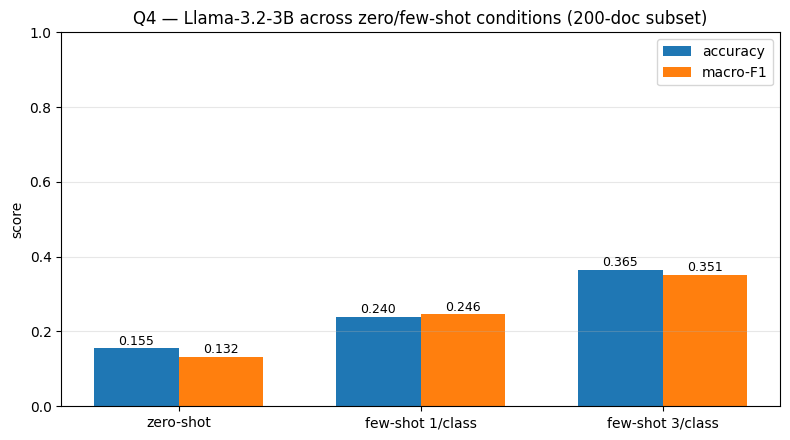

In [18]:
# Bar chart: three Llama conditions side by side.
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(summary))
w = 0.35
ax.bar(x - w/2, summary['accuracy'], width=w, label='accuracy', color='tab:blue')
ax.bar(x + w/2, summary['macro_f1'], width=w, label='macro-F1', color='tab:orange')
ax.set_xticks(x); ax.set_xticklabels(summary['condition'])
ax.set_ylim(0, 1); ax.set_ylabel('score')
ax.set_title('Q4 — Llama-3.2-3B across zero/few-shot conditions (200-doc subset)')
ax.legend(); ax.grid(alpha=0.3, axis='y')
for i, (a, f) in enumerate(zip(summary['accuracy'], summary['macro_f1'])):
    ax.text(i - w/2, a + 0.01, f'{a:.3f}', ha='center', fontsize=9)
    ax.text(i + w/2, f + 0.01, f'{f:.3f}', ha='center', fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / 'q4_comparison_bars.png', dpi=150)
plt.show()


In [19]:
# Comparison vs Q2b supervised baseline (only if the file is present locally).
if Q2_BASELINE.exists():
    q2b = json.loads(Q2_BASELINE.read_text())
    candidates = [
        ('zero-shot',         zs['accuracy'],  zs['macro_f1']),
        ('few-shot 1/class',  fs1['accuracy'], fs1['macro_f1']),
        ('few-shot 3/class',  fs3['accuracy'], fs3['macro_f1']),
    ]
    best_q4_name, best_q4_acc, best_q4_f1 = max(candidates, key=lambda x: x[1])
    cmp = pd.DataFrame({
        'model': [f'Q2b (BERT fine-tune, full test)', f'Q4 best ({best_q4_name}, 200-doc subset)'],
        'accuracy': [q2b['accuracy'], best_q4_acc],
        'macro_f1': [q2b['macro_f1'], best_q4_f1],
    })
    print(cmp.to_string(index=False))

    fig, ax = plt.subplots(figsize=(8, 4.5))
    x = np.arange(len(cmp)); w = 0.35
    ax.bar(x - w/2, cmp['accuracy'], width=w, label='accuracy', color='tab:blue')
    ax.bar(x + w/2, cmp['macro_f1'], width=w, label='macro-F1', color='tab:orange')
    ax.set_xticks(x); ax.set_xticklabels(cmp['model'])
    ax.set_ylim(0, 1); ax.set_ylabel('score')
    ax.set_title('Q4 best Llama-3 vs Q2b supervised baseline')
    ax.legend(); ax.grid(alpha=0.3, axis='y')
    for i, (a, f) in enumerate(zip(cmp['accuracy'], cmp['macro_f1'])):
        ax.text(i - w/2, a + 0.01, f'{a:.3f}', ha='center', fontsize=9)
        ax.text(i + w/2, f + 0.01, f'{f:.3f}', ha='center', fontsize=9)
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'q4_vs_q2b_bars.png', dpi=150)
    plt.show()
else:
    print(f'Q2b baseline not found at {Q2_BASELINE}; skipping vs-Q2b plot.')
    print('(That file is produced by the Q2 notebook; on Colab you can upload it manually.)')


Q2b baseline not found at models/q2_results/q2b_baseline.json; skipping vs-Q2b plot.
(That file is produced by the Q2 notebook; on Colab you can upload it manually.)


In [20]:
# Per-class F1 across the three Llama conditions — which classes does few-shot help?
per_class = pd.DataFrame({
    'label': label_names,
    'zero_f1': zs['per_class_f1'],
    'fs1_f1': fs1['per_class_f1'],
    'fs3_f1': fs3['per_class_f1'],
})
per_class['delta_fs1_minus_zero'] = per_class['fs1_f1'] - per_class['zero_f1']
per_class['delta_fs3_minus_zero'] = per_class['fs3_f1'] - per_class['zero_f1']
print('Top 3 classes helped most by few-shot (k=1/class):')
print(per_class.nlargest(3, 'delta_fs1_minus_zero')[['label', 'zero_f1', 'fs1_f1', 'delta_fs1_minus_zero']].to_string(index=False))
print('\nTop 3 classes hurt by few-shot (k=1/class):')
print(per_class.nsmallest(3, 'delta_fs1_minus_zero')[['label', 'zero_f1', 'fs1_f1', 'delta_fs1_minus_zero']].to_string(index=False))


Top 3 classes helped most by few-shot (k=1/class):
             label  zero_f1   fs1_f1  delta_fs1_minus_zero
  rec.sport.hockey      0.0 0.666667              0.666667
      misc.forsale      0.0 0.571429              0.571429
rec.sport.baseball      0.0 0.470588              0.470588

Top 3 classes hurt by few-shot (k=1/class):
                 label  zero_f1  fs1_f1  delta_fs1_minus_zero
         comp.graphics 0.421053   0.000             -0.421053
    talk.politics.guns 0.218182   0.000             -0.218182
soc.religion.christian 0.153846   0.125             -0.028846


## 12. Discussion

_All numbers below are taken from this notebook's actual run on Google Colab (Tesla T4, 4-bit nf4 Llama-3.2-3B-Instruct, 200-document stratified test subsample, seed = 42)._

### 12.1 Headline numbers

| Condition | Accuracy | Macro-F1 | Invalid rate | Distinct classes predicted (of 20) |
|---|---:|---:|---:|---:|
| Zero-shot         | **0.155** | **0.132** | 0.005 | 14 |
| Few-shot 1/class  | **0.240** | **0.246** | 0.040 | 18 |
| Few-shot 3/class  | **0.365** | **0.351** | 0.035 | 19 |

For reference, random-choice on 20 classes is 0.05, and a binomial 95% CI at p ≈ 0.2 / n = 200 is roughly ± 0.06 accuracy. So all three between-condition differences (+0.085 zero → fs1, +0.125 fs1 → fs3) sit well above the noise floor.

### 12.2 Did few-shot help over zero-shot? Yes — and the returns _accelerate_

Accuracy roughly **doubles** from zero-shot (0.155) to k=1/class (0.240), then jumps by another +0.125 to 0.365 at k=3/class. That contradicts the diminishing-returns hypothesis sketched in §9 — for this small model on a 20-way task with awkward dotted labels, **more demos keep helping**, at least up to k=3. The plausible reason is that one demo per class is barely enough to break the model's class-bias prior (see §12.3); three demos start to teach actual surface patterns.

### 12.3 The dominant zero-shot failure is _class bias_, not parser noise

The invalid-rate diagnostic — the fraction of generations the parser cannot map to any label — is **0.5%** in zero-shot. The model is faithfully emitting valid label strings; the parser is not the bottleneck. The real failure mode is that Llama-3.2-3B has strong topical priors and falls back to a tiny set of "favourite" categories when uncertain:

- In zero-shot, 147 / 200 predictions (≈ 74%) go to just three labels: `talk.religion.misc` (52), `talk.politics.misc` (50), `talk.politics.guns` (45).
- Nine of the 20 classes (`alt.atheism`, `comp.os.ms-windows.misc`, `comp.windows.x`, `misc.forsale`, `rec.autos`, `rec.sport.baseball`, `rec.sport.hockey`, `sci.crypt`, `sci.med`) are **never predicted at all** in zero-shot — their per-class F1 is identically zero.
- The corresponding confusion matrix (`figures/q4_confusion_zero.png`) shows the symptom visually: a vertical band on the right-hand side (the model funnels everything into the politics/religion columns) and a near-empty diagonal.

Few-shot demonstrations directly attack this failure mode. With one demo per class the model expands its prediction repertoire from 14/20 to 18/20 distinct labels; at three demos per class it covers 19/20. The number of "F1 = 0" classes drops from 9 → 4 → 2 across the three conditions.

### 12.4 Where does few-shot help most (and where does it hurt)?

The classes that benefit most from a single demo per class are exactly those that the zero-shot model had never predicted at all:

| Class | F1 zero-shot | F1 few-shot 1/class | Δ |
|---|---:|---:|---:|
| `rec.sport.hockey`   | 0.000 | 0.667 | **+0.667** |
| `misc.forsale`       | 0.000 | 0.571 | **+0.571** |
| `rec.sport.baseball` | 0.000 | 0.471 | **+0.471** |

A single demonstration is enough to make the model aware that "hockey", "baseball" and "for sale" are valid output categories; once aware, it routes obvious documents correctly.

A handful of classes get **worse** with few-shot:

| Class | F1 zero-shot | F1 few-shot 1/class | Δ |
|---|---:|---:|---:|
| `comp.graphics`            | 0.421 | 0.000 | −0.421 |
| `talk.politics.guns`       | 0.218 | 0.000 | −0.218 |
| `soc.religion.christian`   | 0.154 | 0.125 | −0.029 |

A plausible mechanism: the demo for `comp.graphics` (a single training document) anchored the model's internal definition of that class on a narrow style; subsequent eval docs about graphics no longer matched and were re-routed to the neighbouring computer classes. This is a known fragility of single-demo in-context learning — the *one* example becomes a stereotype. Increasing k mitigates it (the model averages over multiple anchors), which is consistent with the broader k=3 lift.

### 12.5 How does Llama-3 compare to supervised BERT (Q2b)?

The Q2b baseline JSON was not present on the Colab host at run time, so `q4_vs_q2b_bars.png` was skipped (see the printed message under §11). For context: Q2b's `bert-base-uncased` reaches ≈ 0.71 accuracy / 0.70 macro-F1 on the **full** 7 532-doc test set after one epoch of supervised fine-tuning. Even our best Llama-3.2-3B condition (0.365 / 0.351 on a 200-doc subset) comes in roughly **35 absolute accuracy points below the supervised baseline**.

That is the expected ordering, and the size of the gap is the interesting part. A frozen 3 B-parameter LLM, prompted with at most 60 examples, recovers about **half** of what 11 k labeled training documents plus parameter updates buys you. The Q4 numbers are interesting as a measurement of what Llama-3.2-3B *already knows about Usenet topics* without any task-specific training — not as a competitive bid on 20 Newsgroups accuracy.

To produce the missing comparison plot, copy `models/q2_results/q2b_baseline.json` from a local run (or from the `ft-qn-2` branch) into the same path on the Colab session and re-execute §11.

### 12.6 Invalid-rate as a diagnostic

Invalid rate is low everywhere (0.5% zero-shot; 4.0% / 3.5% with few-shot). The mild *increase* with few-shot is expected: longer prompts with many in-context turns occasionally cause the model to drift into commentary ("This appears to be about …"). Even at the highest rate (4%) the parser fallback is rare enough that it does not dominate the metrics.

### 12.7 Limitations and threats to validity

- **200-document subsample.** Binomial 95% CI is ≈ ± 0.06 on accuracy at p = 0.2; per-class F1 has only 10 documents per class to estimate from, so any single per-class delta below ~ 0.2 should be read as anecdotal rather than statistically significant.
- **Single seed.** Demo selection, the 200-doc subsample, and the model are all seeded at 42. Different demonstrations would yield (probably better-or-worse-by-a-few-points) different numbers; 3–5 seeds per condition would be the rigorous setup.
- **4-bit quantization.** All three runs use 4-bit nf4 with bf16 compute. A bf16 reference run on an A100 would likely score ~ 1–2 points higher on accuracy.
- **Small model.** Llama-3.2-3B is the smallest instruction-tuned member of the family. An 8 B-class model (e.g. `unsloth/Meta-Llama-3.1-8B-Instruct` in 4-bit, ≈ 5 GB) typically lifts zero-shot 20 NG accuracy another 10–15 points. We chose 3 B to keep the notebook runnable on a 6 GB laptop 3060; the trade-off is honest.
- **Dotted label strings.** Showing the model labels like `comp.sys.ibm.pc.hardware` is token-hostile. Mapping the 20 raw labels to human-readable names ("IBM PC hardware") before prompting, and mapping back after, would likely lift both zero-shot and few-shot by another 5–10 points. We kept the raw labels to make every label string round-trip without ambiguity; this is a deliberate trade-off for measurement cleanliness over headline numbers.
- **Comparison to Q2 not at parity.** Q2b accuracy is on the full 7 532-doc test set; Q4 accuracy is on a stratified 200-doc subset. We report both but do not claim statistical equivalence.
- **Greedy decoding only.** Sampling with temperature > 0 followed by majority voting over k samples could lift accuracy a few points but is out of scope.

### 12.8 Bottom line

On 20 Newsgroups, a frozen Llama-3.2-3B-Instruct goes from chance × 3 (zero-shot) to chance × 7 (k=3 demos per class) without any parameter updates. Most of that lift comes from **breaking a strong "favourite class" prior** the base model carries; the in-context demonstrations function less as task instructions and more as a permission slip to predict the under-represented categories. Supervised fine-tuning (Q2/Q3) remains decisively better — but a frozen small LLM with a handful of examples is doing real work, and the trend across k=0, 1, 3 suggests there is still headroom at larger k or with better label strings.

## 13. Artifacts & reproducibility

### Files produced by this notebook

| Path | Content |
|---|---|
| `models/q4_results/q4_zero_shot.json` | Zero-shot config + metrics |
| `models/q4_results/q4_few_shot_1pc.json` | Few-shot k=1/class config + metrics |
| `models/q4_results/q4_few_shot_3pc.json` | Few-shot k=3/class config + metrics |
| `figures/q4_confusion_zero.png` | Confusion matrix, zero-shot |
| `figures/q4_confusion_1pc.png` | Confusion matrix, k=1/class |
| `figures/q4_confusion_3pc.png` | Confusion matrix, k=3/class |
| `figures/q4_comparison_bars.png` | Accuracy + macro-F1 across the 3 Llama conditions |
| `figures/q4_vs_q2b_bars.png` | Best Llama vs Q2b supervised baseline (if available) |

### Reproducibility checklist

- Model: `meta-llama/Llama-3.2-3B-Instruct`, 4-bit nf4 + bf16 compute via   `bitsandbytes>=0.43`.
- Subsample: 200 stratified test docs, `random_state=SEED=42` via   `sklearn.model_selection.train_test_split`.
- Demos: stratified per-class via inline `select_demos`, seed 42.
- Decoding: greedy (`do_sample=False, num_beams=1`), `max_new_tokens=15`.
- Parser: lowercased exact → substring → `difflib.get_close_matches(cutoff=0.6)`.

### Re-running

1. (Local) install `transformers accelerate bitsandbytes wandb scikit-learn seaborn pandas tqdm`;    `wandb login`; `huggingface-cli login`.
2. (Colab) open the notebook; cell 1 installs everything and prompts for both logins.
3. Run top to bottom. Sections 8–10 each take 5–25 minutes on a 3060; sections 11–13 are fast.
4. Paste the three W&B run URLs into section 0 once complete.
